In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets

In [ ]:
!pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 39.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
import transformers, sys
print("python:", sys.version)
print("transformers:", transformers.__version__)
print("transformers path:", transformers.__file__)

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
transformers: 4.57.6
transformers path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
!pip install -U setuptools wheel packaging
!pip uninstall -y transformers tokenizers
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.1 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: wheel
    Found existing installation: wheel 0.45.1
    Uninstalling wheel-0.45.1:
      Successfully uninstalled wheel-0.45.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [wheel]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
langchain-core 1.2.7 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0 which is incompatible.


Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.0.0-py3-none-any.whl (10.1 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
ERROR: Operation cancelled by user
^C


In [ ]:
!pip install -U pip
!pip uninstall -y transformers tokenizers
!pip install -U transformers


  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.0.0-py3-none-any.whl (10.1 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers]


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
print("transformers import OK")

transformers import OK


In [ ]:
#from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import pandas as pd


model_name = 'beomi/KcELECTRA-base-v2022'
tokenizer = AutoTokenizer.from_pretrained(model_name)
#model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=9)
model = AutoModelForSequenceClassification.from_pretrained(
     model_name,
     num_labels=9,
     problem_type="multi_label_classification")

# Ensure all tensors are contiguous
for param in model.parameters():
    if not param.is_contiguous():
        param.data = param.data.contiguous()

model.save_pretrained("/kcELECTRA_base_model_v2025")
tokenizer.save_pretrained("/kcELECTRA_base_model_v2025")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base-v2022 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


('/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2025/tokenizer_config.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2025/special_tokens_map.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2025/vocab.txt',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2025/added_tokens.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2025/tokenizer.json')

## KcELECTRA V.2025

In [ ]:
import pandas as pd
train = pd.read_csv("/KOR_hatespeech_all_train.csv")
print(train.columns.tolist())

dev = pd.read_csv("/KOR_hatespeech_all_dev.csv")
print(dev.columns.tolist())

['comments', 'label']
['comments', 'label']


# Ver.1

In [ ]:
%time

import json
import numpy as np
import torch
import pandas as pd
import evaluate

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers.trainer_callback import TrainerCallback

# =========================
# 0) 모델/토크나이저 로드
# =========================
model_path = "/kcELECTRA_base_model_v2025"
tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=9,
    problem_type="multi_label_classification"
)

# (선택) contiguous 처리
for param in model.parameters():
    if not param.is_contiguous():
        param.data = param.data.contiguous()

# =========================
# 1) 문자열 label -> 멀티핫 labels 변환
# =========================
NUM_LABELS = 9

def str_to_multihot(s, num_labels=NUM_LABELS):
    if pd.isna(s):
        return [0.0] * num_labels
    s = str(s).strip()
    if s == "":
        return [0.0] * num_labels

    idxs = [int(x) for x in s.split(",") if x.strip() != ""]

    # 규칙: 8은 단독
    if 8 in idxs:
        idxs = [8]

    vec = [0.0] * num_labels
    for i in idxs:
        if 0 <= i < num_labels:
            vec[i] = 1.0
    return vec

# =========================
# 2) train/dev 로드 + Dataset 생성
#   - CSV 원본 컬럼명은 label 그대로 둬도 됨
#   - Trainer가 쓰는 컬럼은 labels로 만들어서 넘김
# =========================
train = pd.read_csv("/KOR_hatespeech_all_train.csv")

# 파일이 (comments, label) 두 컬럼이라고 가정하고 이름만 통일
train.columns = ["comments", "label"]

train = train.dropna(subset=["label"]).reset_index(drop=True)
train["comments"] = train["comments"].fillna("").astype(str)

# 핵심: labels 컬럼을 새로 생성 (멀티핫)
train["labels"] = train["label"].apply(str_to_multihot)

# 학습용 Dataset에는 comments + labels만 넣기
train_dataset = Dataset.from_pandas(train[["comments", "labels"]], preserve_index=False)
print(">> training dataset:", train.shape)

dev = pd.read_csv("/KOR_hatespeech_all_dev.csv")
dev.columns = ["comments", "label"]

dev = dev.dropna(subset=["label"]).reset_index(drop=True)
dev["comments"] = dev["comments"].fillna("").astype(str)

# 핵심: labels 컬럼을 새로 생성 (멀티핫)
dev["labels"] = dev["label"].apply(str_to_multihot)

dev_dataset = Dataset.from_pandas(dev[["comments", "labels"]], preserve_index=False)
print(">> dev dataset:", dev.shape)

# =========================
# 3) 토크나이즈
# =========================
def preprocess_function(examples):
    return tokenizer(
        examples["comments"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True)
tokenized_dev_dataset = dev_dataset.map(preprocess_function, batched=True)

# Trainer가 labels를 텐서로 보게 포맷 지정
tokenized_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# =========================
# (추가) 멀티레이블 라벨이 제대로 들어갔는지 확인
# =========================
sample = tokenized_train_dataset[0]
print(">> keys:", sample.keys())
print(">> labels type:", type(sample["labels"]))
print(">> labels length:", len(sample["labels"]))
print(">> labels:", sample["labels"])

# 배치 형태 확인(Trainer에 들어갈 때와 유사하게)
from torch.utils.data import DataLoader
loader = DataLoader(tokenized_train_dataset, batch_size=8)
batch = next(iter(loader))
print(">> batch labels shape:", batch["labels"].shape)  # 기대: torch.Size([8, 9])
print(">> batch labels dtype:", batch["labels"].dtype)  # 기대: float 계열

# =========================
# 4) 멀티레이블용 metrics (micro/macro F1)
# =========================
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    # Trainer가 넘겨주는 형태(EvalPrediction)와 튜플 형태 둘 다 대응
    logits = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]

    probs = 1 / (1 + np.exp(-logits))          # sigmoid
    preds = (probs >= 0.5).astype(int)         # (N, 9) 0/1
    y_true = (labels >= 0.5).astype(int)       # labels가 float32일 수 있어서 안전하게 int로

    return {
        "f1_micro": f1_score(y_true, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, preds, average="macro", zero_division=0),
    }


# =========================
# 5) 로그 저장 콜백
# =========================
class CustomTrainerCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            with open("/train_eval_logs_lr2e-5_ep4.json", "a") as f:
                json.dump(logs, f, indent=4)
                f.write("\n")

# =========================
# 6) TrainingArguments
# =========================
training_args = TrainingArguments(
    output_dir=model_path + "/results_lr_2e-5_ep4",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="/experiment_v2025_lr2e-5_ep4",
    load_best_model_at_end=True,
    report_to=[]
)

# =========================
# 7) Trainer
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[CustomTrainerCallback()]
)

# =========================
# 8) 학습/평가/저장
# =========================
trainer.train()

log_history = trainer.state.log_history
with open("/logs_lr2e-5_ep4.json", "w") as f:
    json.dump(log_history, f, indent=4)

trainer.evaluate()

model.save_pretrained("/ft_kcELECTRA_model_lr2e-5_ep4")
tokenizer.save_pretrained("/ft_kcELECTRA_model_lr2e-5_ep4")


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.72 µs
>> training dataset: (92311, 3)
>> dev dataset: (23077, 3)


Map:   0%|          | 0/92311 [00:00<?, ? examples/s]

Map:   0%|          | 0/23077 [00:00<?, ? examples/s]

>> keys: dict_keys(['labels', 'input_ids', 'attention_mask'])
>> labels type: <class 'torch.Tensor'>
>> labels length: 9
>> labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 1.])
>> batch labels shape: torch.Size([8, 9])
>> batch labels dtype: torch.float32


/tmp/ipython-input-2583333370.py:171: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.156200,0.128302,0.802735,0.799538


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.156200,0.128302,0.802735,0.799538
2,0.105100,0.131667,0.811140,0.804760
3,0.074700,0.158189,0.808695,0.805418
4,0.052600,0.181878,0.809092,0.807148


('/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/ft_kcELECTRA_model_lr2e-5_ep4/tokenizer_config.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/ft_kcELECTRA_model_lr2e-5_ep4/special_tokens_map.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/ft_kcELECTRA_model_lr2e-5_ep4/vocab.txt',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/ft_kcELECTRA_model_lr2e-5_ep4/added_tokens.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/ft_kcELECTRA_model_lr2e-5_ep4/tokenizer.json')

In [ ]:
import os
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ====== (A) 이전 0~8 학습 모델 경로 ======
old_model_dir = "/ft_kcELECTRA_model_lr2e-5_ep4"

tokenizer = AutoTokenizer.from_pretrained(old_model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    old_model_dir,
    num_labels=9,
    problem_type="multi_label_classification"
)

# ====== (B) dev 로드 (원본은 그대로 둠) ======
dev_path = "/KOR_hatespeech_all_dev.csv"
dev = pd.read_csv(dev_path)
dev.columns = ["comments", "label"]
dev = dev.dropna(subset=["label"]).reset_index(drop=True)
dev["comments"] = dev["comments"].fillna("").astype(str)

dev_dataset = Dataset.from_pandas(dev[["comments"]], preserve_index=False)

# ====== (C) 토크나이즈 ======
def preprocess_function(examples):
    return tokenizer(examples["comments"], truncation=True, padding="max_length", max_length=512)

tokenized_dev = dev_dataset.map(preprocess_function, batched=True)
tokenized_dev.set_format(type="torch", columns=["input_ids", "attention_mask"])

# ====== (D) 예측 ======
import torch
from torch.utils.data import DataLoader

model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

loader = DataLoader(tokenized_dev, batch_size=16)

all_logits = []
device = next(model.parameters()).device

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        all_logits.append(out.logits.detach().cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
probs = 1 / (1 + np.exp(-logits))
pred_bin = (probs >= 0.5).astype(int)

# ====== (E) 저장용 문자열 변환: (원본 방식) 0~8 모두 사용 가능 ======
def vec_to_str_raw9(vec):
    idxs = [i for i, v in enumerate(vec) if v == 1]
    return "" if len(idxs) == 0 else ",".join(map(str, idxs))

pred_label_raw = [vec_to_str_raw9(row) for row in pred_bin]

# ====== (F) 저장 폴더/파일 ======
OUT_DIR = "/Model_2025"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) 예측 라벨만
pd.DataFrame({"pred_label": pred_label_raw}).to_csv(
    os.path.join(OUT_DIR, "dev_pred_label_only_0to8_raw.csv"),
    index=False
)

# 2) 확률까지(0~8)
out = pd.DataFrame({"pred_label": pred_label_raw})
for i in range(9):
    out[f"prob_{i}"] = probs[:, i]

out.to_csv(
    os.path.join(OUT_DIR, "dev_pred_with_probs_0to8_raw.csv"),
    index=False
)

print("Saved to:", OUT_DIR)


Map:   0%|          | 0/23077 [00:00<?, ? examples/s]

Saved to: /content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025


# Ver. 2

In [ ]:
#from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import pandas as pd


model_name = 'beomi/KcELECTRA-base-v2022'
tokenizer = AutoTokenizer.from_pretrained(model_name)
#model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=8)
model = AutoModelForSequenceClassification.from_pretrained(
     model_name,
     num_labels=8,
     problem_type="multi_label_classification")

# Ensure all tensors are contiguous
for param in model.parameters():
    if not param.is_contiguous():
        param.data = param.data.contiguous()

model.save_pretrained("/kcELECTRA_base_model_v2026")
tokenizer.save_pretrained("/kcELECTRA_base_model_v2026")

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base-v2022 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


('/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2026/tokenizer_config.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2026/special_tokens_map.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2026/vocab.txt',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2026/added_tokens.json',
 '/content/drive/MyDrive/MP_KORHateSpeechDetection/Model/kcELECTRA_base_model_v2026/tokenizer.json')

In [ ]:
%time

import os
import json
import numpy as np
import torch
import pandas as pd

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers.trainer_callback import TrainerCallback

from sklearn.metrics import f1_score, accuracy_score

# ============================================================
# A) 저장해둔 8라벨 모델/토크나이저 로드 (0~7만 학습, 8은 규칙으로 부여)
# ============================================================
model_path = "/kcELECTRA_base_model_v2026"
tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=8,
    problem_type="multi_label_classification"
)

# ============================================================
# 1) 라벨 변환: 문자열("3,5") -> 멀티핫(길이 8, 0~7만)
#    - gold에 8이 있으면 "비혐오"이므로 멀티핫은 전부 0으로 둠
# ============================================================
NUM_LABELS = 8  # 0~7

def str_to_multihot_0to7(s, num_labels=NUM_LABELS):
    if pd.isna(s):
        return [0.0] * num_labels
    s = str(s).strip()
    if s == "":
        return [0.0] * num_labels

    idxs = [int(x) for x in s.split(",") if x.strip() != ""]

    # 규칙: 8은 단독(비혐오) -> 학습 라벨(0~7)은 전부 0 처리
    if 8 in idxs:
        return [0.0] * num_labels

    vec = [0.0] * num_labels
    for i in idxs:
        if 0 <= i < num_labels:  # 0~7만
            vec[i] = 1.0
    return vec

# 예측(0~7 멀티핫) -> 문자열 (아무것도 없으면 8)
def pred_vec_to_str_rule(vec01):
    idxs = [i for i in range(8) if int(vec01[i]) == 1]
    return "8" if len(idxs) == 0 else ",".join(map(str, idxs))

# ============================================================
# 2) 데이터 로드 + Dataset 생성
#    - 원본 CSV는 (comments, label)이라고 가정
# ============================================================
train_path = "/KOR_hatespeech_all_train.csv"
dev_path   = "/KOR_hatespeech_all_dev.csv"

train = pd.read_csv(train_path)
train.columns = ["comments", "label"]

train = train.dropna(subset=["label"]).reset_index(drop=True)
train["comments"] = train["comments"].fillna("").astype(str)
train["labels"] = train["label"].apply(str_to_multihot_0to7)

train_dataset = Dataset.from_pandas(train[["comments", "labels"]], preserve_index=False)
print(">> training dataset:", train.shape)

dev = pd.read_csv(dev_path)
dev.columns = ["comments", "label"]

dev = dev.dropna(subset=["label"]).reset_index(drop=True)
dev["comments"] = dev["comments"].fillna("").astype(str)
dev["labels"] = dev["label"].apply(str_to_multihot_0to7)

dev_dataset = Dataset.from_pandas(dev[["comments", "labels"]], preserve_index=False)
print(">> dev dataset:", dev.shape)

# ============================================================
# 3) 토크나이즈
#    - 지금은 기존대로 max_length=512 고정 패딩
# ============================================================
def preprocess_function(examples):
    return tokenizer(
        examples["comments"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True)
tokenized_dev_dataset = dev_dataset.map(preprocess_function, batched=True)

tokenized_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# (확인) labels shape가 (batch, 8)인지 체크
from torch.utils.data import DataLoader
batch = next(iter(DataLoader(tokenized_train_dataset, batch_size=8)))
print(">> batch labels shape:", batch["labels"].shape)   # 기대: torch.Size([8, 8])
print(">> batch labels dtype:", batch["labels"].dtype)

# ============================================================
# 4) 멀티레이블용 metrics (0~7 기준)
#    - f1_micro/macro: 0~7에 대해 계산
#    - subset_accuracy_0to7: 0~7 벡터 완전일치
#    - acc_hate_vs_8_rule: "혐오(0~7 중 하나라도 1) vs 비혐오(전부 0)" 이진 정확도
# ============================================================
def compute_metrics(eval_pred):
    logits = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]

    probs = 1 / (1 + np.exp(-logits))           # sigmoid
    preds = (probs >= 0.5).astype(int)          # (N, 8)
    y_true = (labels >= 0.5).astype(int)        # (N, 8)

    f1_micro = f1_score(y_true, preds, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, preds, average="macro", zero_division=0)
    subset_acc_0to7 = accuracy_score(y_true, preds)

    # 8 규칙 적용 관점에서: "혐오 있음(H) vs 비혐오(8)"
    pred_is_hate = (preds.sum(axis=1) > 0).astype(int)
    gold_is_hate = (y_true.sum(axis=1) > 0).astype(int)
    acc_hate_vs_8 = accuracy_score(gold_is_hate, pred_is_hate)

    return {
        "f1_micro_0to7": f1_micro,
        "f1_macro_0to7": f1_macro,
        "subset_accuracy_0to7": subset_acc_0to7,
        "acc_hate_vs_8_rule": acc_hate_vs_8
    }

# ============================================================
# 5) 로그 저장 콜백
# ============================================================
OUT_DIR = "/Model_2026"
os.makedirs(OUT_DIR, exist_ok=True)

class CustomTrainerCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            with open(os.path.join(OUT_DIR, "train_eval_logs.jsonl"), "a") as f:
                f.write(json.dumps(logs) + "\n")

# ============================================================
# 6) TrainingArguments
# ============================================================
training_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "results_lr_2e-5_ep4"),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir=os.path.join(OUT_DIR, "logs"),
    load_best_model_at_end=True,
    report_to=[]
    # fp16=True  # A100이면 켜도 됩니다. 필요하면 주석 해제
)

# ============================================================
# 7) Trainer
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[CustomTrainerCallback()]
)

# ============================================================
# 8) 학습/평가/저장
# ============================================================
trainer.train()
trainer.evaluate()

model.save_pretrained(os.path.join(OUT_DIR, "ft_kcELECTRA_no8label_lr2e-5_ep4"))
tokenizer.save_pretrained(os.path.join(OUT_DIR, "ft_kcELECTRA_no8label_lr2e-5_ep4"))

# ============================================================
# 9) 예측 결과만 별도 저장 (원본 파일은 그대로)
#    - pred_label_only: "8 규칙" 적용된 문자열 라벨만 저장
#    - pred_with_probs: prob_0~prob_7까지 저장
# ============================================================
pred_out = trainer.predict(tokenized_dev_dataset)
logits = pred_out.predictions
probs = 1 / (1 + np.exp(-logits))
pred_bin = (probs >= 0.5).astype(int)

pred_label = [pred_vec_to_str_rule(row) for row in pred_bin]

# 예측 라벨만 저장
pd.DataFrame({"pred_label": pred_label}).to_csv(
    os.path.join(OUT_DIR, "dev_pred_label_only.csv"),
    index=False
)

# 확률까지 저장
out = pd.DataFrame({"pred_label": pred_label})
for i in range(8):
    out[f"prob_{i}"] = probs[:, i]

out.to_csv(
    os.path.join(OUT_DIR, "dev_pred_with_probs.csv"),
    index=False
)

print("Saved outputs to:", OUT_DIR)


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.68 µs
>> training dataset: (92311, 3)
>> dev dataset: (23077, 3)


Map:   0%|          | 0/92311 [00:00<?, ? examples/s]

Map:   0%|          | 0/23077 [00:00<?, ? examples/s]

>> batch labels shape: torch.Size([8, 8])
>> batch labels dtype: torch.float32


/tmp/ipython-input-1556823220.py:172: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1 Micro 0to7,F1 Macro 0to7,Subset Accuracy 0to7,Acc Hate Vs 8 Rule
1,0.138800,0.114144,0.804979,0.794998,0.731551,0.869654
2,0.093400,0.113042,0.816588,0.808928,0.748971,0.888287
3,0.066800,0.131852,0.814784,0.809752,0.748104,0.887507
4,0.046900,0.150802,0.812112,0.806984,0.745158,0.887550


Saved outputs to: /content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2026


In [ ]:
%time
import os
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# ============================================================
# 0) 학습된 모델 로드 (0~7만 학습된 8라벨 모델)
#    - 반드시 "학습 완료 후 저장된 경로"로 지정하세요.
# ============================================================
FT_DIR = "/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2026/ft_kcELECTRA_no8label_lr2e-5_ep4"
OUT_DIR = "/content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2026"
os.makedirs(OUT_DIR, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(FT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    FT_DIR,
    num_labels=8,
    problem_type="multi_label_classification"
)

# ============================================================
# 1) dev 로드 (중요: label로 dropna 하지 마세요)
#    - 원본 행 수(23078)가 그대로 유지돼야 합니다.
# ============================================================
dev_path = "/content/drive/MyDrive/MP_KORHateSpeechDetection/KOR_hatespeech_all_dev.csv"
dev = pd.read_csv(dev_path)

# 파일이 (comments, label) 2컬럼이라고 가정
dev.columns = ["comments", "label"]

# row_id로 1:1 매칭 보장
dev["row_id"] = np.arange(len(dev))

# comments만 있으면 예측 가능
dev["comments"] = dev["comments"].fillna("").astype(str)

print(">> dev rows loaded:", len(dev))  # 여기서 23078이어야 정상

# ============================================================
# 2) Dataset 생성 + 토크나이즈
# ============================================================
dev_dataset = Dataset.from_pandas(dev[["row_id", "comments"]], preserve_index=False)

def preprocess_function(examples):
    return tokenizer(
        examples["comments"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_dev = dev_dataset.map(preprocess_function, batched=True)
tokenized_dev.set_format(type="torch", columns=["input_ids", "attention_mask"])

# ============================================================
# 3) 추론만 실행 (재학습 X)
# ============================================================
args = TrainingArguments(
    output_dir="/tmp/predict_only",
    per_device_eval_batch_size=16,
    report_to=[]
)
trainer = Trainer(model=model, args=args)

pred_out = trainer.predict(tokenized_dev)
logits = pred_out.predictions                      # (N, 8)
probs = 1 / (1 + np.exp(-logits))                  # sigmoid
pred_bin = (probs >= 0.5).astype(int)              # (N, 8)

# ============================================================
# 4) 8 규칙 적용해서 문자열 라벨 생성
#    - 0~7 중 아무것도 없으면 "8"
# ============================================================
def pred_vec_to_str_rule(vec01):
    idxs = [i for i in range(8) if int(vec01[i]) == 1]
    return "8" if len(idxs) == 0 else ",".join(map(str, idxs))

pred_label = [pred_vec_to_str_rule(row) for row in pred_bin]

# 길이 체크: 반드시 dev rows와 같아야 함
print(">> preds:", len(pred_label), " / dev:", len(dev))

# ============================================================
# 5) 저장: (row_id + pred_label)로 반드시 보존
# ============================================================
out_label_only = pd.DataFrame({
    "row_id": dev["row_id"].to_numpy(),
    "pred_label": pred_label
})
out_path1 = os.path.join(OUT_DIR, "dev_pred_label_only_FIXED_LEN.csv")
out_label_only.to_csv(out_path1, index=False)

# (선택) 확률도 같이 저장
out_probs = out_label_only.copy()
for i in range(8):
    out_probs[f"prob_{i}"] = probs[:, i]
out_path2 = os.path.join(OUT_DIR, "dev_pred_with_probs_FIXED_LEN.csv")
out_probs.to_csv(out_path2, index=False)

print("Saved:")
print("-", out_path1)
print("-", out_path2)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.91 µs


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

>> dev rows loaded: 23078


Map:   0%|          | 0/23078 [00:00<?, ? examples/s]

>> preds: 23078  / dev: 23078
Saved:
- /content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2026/dev_pred_label_only_FIXED_LEN.csv
- /content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2026/dev_pred_with_probs_FIXED_LEN.csv


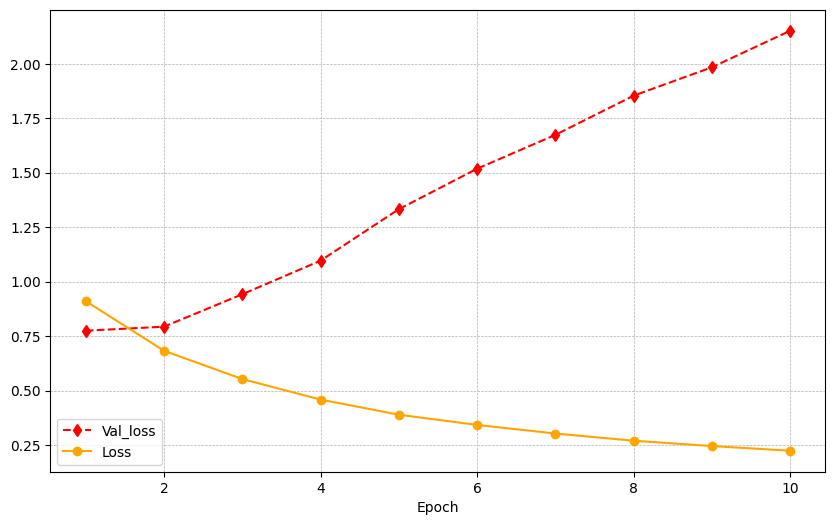

In [ ]:
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1) 경로
model_dir = "/ft_kcELECTRA_model_lr2e-5_ep4"
dev_path   = "/KOR_hatespeech_all_dev.csv"

# 2) 로드
dev = pd.read_csv(dev_path)
dev.columns = ["text", "label"]  # 훈련 코드랑 동일하게 맞춤

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir, num_labels=9)

# 3) Dataset + tokenize
dev_ds = Dataset.from_dict({"text": dev["text"].astype(str).tolist()})

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

tok_dev = dev_ds.map(preprocess_function, batched=True, remove_columns=["text"])

# 4) Trainer는 predict 용도로만 가볍게 생성
args = TrainingArguments(
    output_dir="/content/tmp_kcelectra_pred",
    per_device_eval_batch_size=16,
    report_to=[]
)

trainer = Trainer(model=model, args=args)

# 5) 예측 + 저장
pred_out = trainer.predict(tok_dev)
pred_label = np.argmax(pred_out.predictions, axis=-1).astype(int)

pred_save_path = "/content/drive/MyDrive/MP_KORHateSpeechDetection/kcelectra_dev_pred_lr2e-5_ep4.csv"
dev_for_save = dev.copy()
dev_for_save["pred_label"] = pred_label
dev_for_save.to_csv(pred_save_path, index=False)

print("Saved:", pred_save_path)


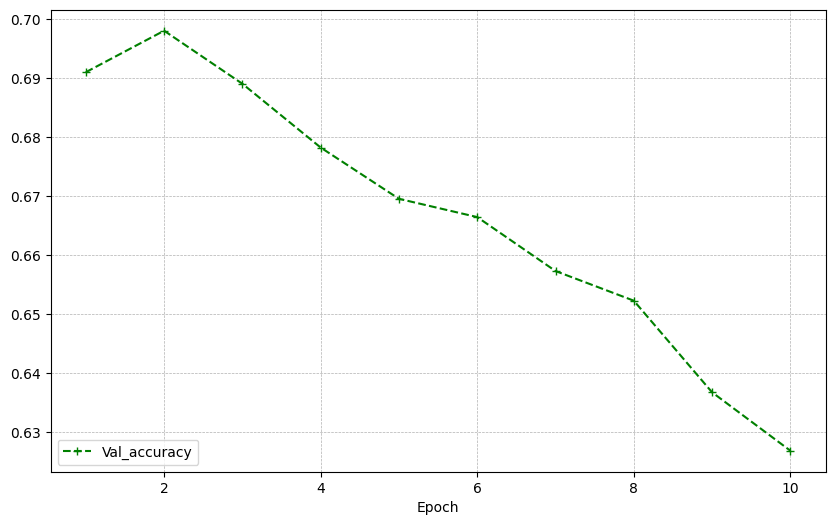

In [ ]:
import matplotlib.pyplot as plt
import json

# Load your log file
log_file_path = '/logs_lr2e-5_ep10.json'
with open(log_file_path, 'r') as f:
    log_history = json.load(f)

# Initialize lists for storing the values
train_loss = []
val_loss = []
val_accuracy = []
epochs = []

# Extract values from log_history
for entry in log_history:
    if 'loss' in entry:  # Training loss
        train_loss.append(entry['loss'])
    if 'eval_loss' in entry:  # Validation loss
        val_loss.append(entry['eval_loss'])
    if 'eval_accuracy' in entry:  # Validation accuracy
        val_accuracy.append(entry['eval_accuracy'])
    if 'epoch' in entry:  # Epochs
        epochs.append(entry['epoch'])

# Ensure we only have 10 epochs for plotting
epochs = list(range(1, 11))  # Adjust if your epoch count is different

# Create the plot
plt.figure(figsize=(10, 6))

# Plot accuracy and loss with proper markers and linestyles
plt.plot(epochs, val_accuracy, label='Val_accuracy', marker='+', linestyle='--', color='green')
# plt.plot(epochs, val_loss, label='Val_loss', marker='d', linestyle='--', color='red')
# plt.plot(epochs, train_loss, label='Loss', marker='o', linestyle='-', color='orange')

# Set ticks for the x-axis (epoch markers at 2, 4, 6, 8, 10)
plt.xticks([2, 4, 6, 8, 10])

# Labeling the plot
plt.xlabel('Epoch')

# Moved legend to the bottom left
plt.legend(loc='lower left')

# Lighter grid
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

# Save the plot to a file
plt.savefig("/kcELECTRA_v2025_accuracy_plot.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

## macro F1 score

In [ ]:
from sklearn.metrics import f1_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load your trained model and tokenizer
model_path = '/ft_kcELECTRA_model_lr2e-5_ep10'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=9)

# Preprocess validation dataset
dev = pd.read_csv('/KOR_hatespeech_all_dev.csv')
dev["labels"] = dev["label"]
dev["text"] = dev["comments"]

# Convert to Dataset (for tokenizing)
data = dev.to_dict(orient='list')
dev_dataset = Dataset.from_dict(data)

# Tokenize the validation dataset
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding="max_length", max_length=512)

tokenized_dev_dataset = dev_dataset.map(preprocess_function, batched=True)

# Setup training arguments for evaluation
training_args = TrainingArguments(
    output_dir=model_path+'/results',
    per_device_eval_batch_size=16,
    report_to=[] # wandb deactiv
)

# Initialize Trainer with compute_metrics
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_dev_dataset
)

# Predict on the validation dataset
predictions = trainer.predict(tokenized_dev_dataset)

# Get predicted logits and true labels
logits = predictions.predictions
labels = predictions.label_ids

# Convert logits to predicted classes
predicted_classes = torch.argmax(torch.tensor(logits), dim=-1)

# Compute Macro F1-Score
macro_f1 = f1_score(labels, predicted_classes, average='macro')
print(f"Macro F1-Score for validation dataset: {macro_f1}")

Map:   0%|          | 0/26470 [00:00<?, ? examples/s]

Macro F1-Score for validation dataset: 0.6820123491707539


## Confusion Matrix

Map:   0%|          | 0/26470 [00:00<?, ? examples/s]

Confusion matrix saved at: /content/drive/MyDrive/MP_KORHateSpeechDetection/Model_2025/confusion_matrix.png


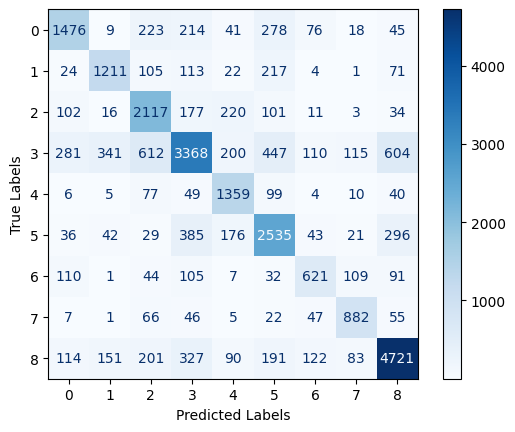

In [ ]:
import torch
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Load your saved model and tokenizer
model_path = '/ft_kcELECTRA_model_lr2e-5_ep10'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=9)

# Load and preprocess validation dataset
dev = pd.read_csv('/KOR_hatespeech_all_dev.csv')
# label_mapping = {"none": 0, "offensive": 1, "hate": 2}
# dev['label'] = dev['label'].replace(label_mapping)


# Convert to Dataset and tokenize
dev_dataset = Dataset.from_pandas(dev)

def preprocess_function(examples):
    return tokenizer(examples['comments'], truncation=True, padding="max_length", max_length=512)

tokenized_dev_dataset = dev_dataset.map(preprocess_function, batched=True)

# Ensure that 'label' is still in the dataset after tokenization
tokenized_dev_dataset = tokenized_dev_dataset.with_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Create DataLoader for validation dataset
dev_dataloader = DataLoader(tokenized_dev_dataset, batch_size=16)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set model to evaluation mode
model.eval()

# Collect predictions and actual labels
all_preds = []
all_labels = []

# No gradients required for evaluation
with torch.no_grad():
    for batch in dev_dataloader:
        # Ensure 'labels' are passed correctly
        inputs = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask']}
        labels = batch['label'].to(device)

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # Get predictions
        predictions = torch.argmax(logits, dim=-1)

        # Store predictions and true labels
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
# plt.title('Confusion Matrix for kcELECTRA Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Save the confusion matrix as a PNG file
confusion_matrix_path = "/confusion_matrix.png"
plt.savefig(confusion_matrix_path, format='png')
print(f"Confusion matrix saved at: {confusion_matrix_path}")

# Show the confusion matrix plot
plt.show()